# Máquinas de Vectores de Soporte (SVM)

**Las máquinas de vectores de soporte (SVM)** son una categoría muy utilizada y poderosa de algoritmos de aprendizaje automático. Hay muchas variaciones en la idea básica de un SVM. Un SVM intenta **separar al máximo** las clases al encontrar el **vector de soporte** con la tasa de error más baja o la separación máxima. Los SVM pueden usar muchos tipos de **funciones del núcleo**. Las funciones del núcleo más comunes son **lineal** y la **función de base radial** o **RBF**. La función de base lineal intenta separar las clases al encontrar hiperplanos en el espacio de características que separan las clases al máximo. El RBF utiliza un conjunto de núcleos locales en forma de Gauss para encontrar una separación no lineal de las clases.


Consiste en seleccionar como clasificador óptimo al que se conoce como maximal margin hyperplane o hiperplano óptimo de separación, que se corresponde con el hiperplano que se encuentra más alejado de todas las observaciones de entrenamiento.
Para obtenerlo, se tiene que calcular la distancia perpendicular de cada observación a un determinado hiperplano. La menor de estas distancias (conocida como margen) determina como de alejado está el hiperplano de las observaciones de entrenamiento.

*https://rpubs.com/Joaquin_AR/267926

## 1. Librerias y configuraciones previas


In [52]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np


# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib


# Gestion de librerias
# ==============================================================================
from importlib import reload


# Matemáticas y estadísticas
# ==============================================================================
import math


# Preprocesado y modelado
# ==============================================================================
import math

#Separar los datos entrenamiento y prueba
from sklearn.model_selection import train_test_split


#Escalar Variables
from sklearn.preprocessing import MinMaxScaler


#Evaluación del modelo
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve


#Creación de modelo
from sklearn import svm


#configuracion de hiperparámetros
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns


#Interuactuar con os y solicitudes desde HTTP
import os
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [53]:
## Definición de variables de entorno y rutas

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/mrbedoya/ml-2026/main/'

# Nombres de los directorios para utilidades, datasets y modelos
UTILS_DIR_NAME = 'utils/'
DATASETS_DIR_NAME = 'datasets/'
MODELS_DIR_NAME = 'modelos/'
CLASIF_DIR_NAME = MODELS_DIR_NAME + 'clasificacion/'
#REGRES_DIR_NAME = MODELS_DIR_NAME + 'regresion/'
SCALER_DIR_NAME = MODELS_DIR_NAME + 'scaler/'


# Nombre del archivo del dataset
DATASET_FILE_NAME = '02_GermanCredit.csv'
FUNCTIONS_FILE_NAME = 'funciones.py'

# Ruta completa de los directorios

# Rutas locales completas a los directorios
UTILS_PATH = UTILS_DIR_NAME
DATASETS_PATH = DATASETS_DIR_NAME
MODELS_PATH = MODELS_DIR_NAME
CLASIF_PATH = CLASIF_DIR_NAME
#REGRES_PATH = REGRES_DIR_NAME
SCALER_PATH = SCALER_DIR_NAME


# URL completa del dataset y archivo de funciones en GitHub
github_dataset_url = os.path.join(GITHUB_BASE_URL, DATASETS_DIR_NAME, DATASET_FILE_NAME)
github_funciones_url = os.path.join(GITHUB_BASE_URL, UTILS_DIR_NAME, FUNCTIONS_FILE_NAME)

# Ruta local completa para guardar el dataset y archivo de funciones
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_funciones_path = os.path.join(UTILS_PATH, FUNCTIONS_FILE_NAME)

In [54]:
## Configuración entorno Colab

# Creación de directorios locales
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(CLASIF_DIR_NAME, exist_ok=True)
#os.makedirs(REGRES_DIR_NAME, exist_ok=True)
os.makedirs(SCALER_DIR_NAME, exist_ok=True)

## Descarga del dataset
print(f"Descargando dataset desde: {github_dataset_url}")
response = requests.get(github_dataset_url)

# Lanza una excepción si la descarga falla (código de estado HTTP no 200)
response.raise_for_status()

# Guardar el contenido descargado en el archivo local
with open(local_dataset_path, 'wb') as f:
    f.write(response.content)

print(f"Dataset descargado exitosamente a: {local_dataset_path}")

## Descarga del archivo de funciones
print(f"Descargando funciones desde: {github_funciones_url}")
response_funciones = requests.get(github_funciones_url)
response_funciones.raise_for_status() # Lanza una excepción si la descarga falla

with open(local_funciones_path, 'wb') as f:
    f.write(response_funciones.content)

print(f"Funciones descargadas exitosamente a: {local_funciones_path}")

Descargando dataset desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/datasets/02_GermanCredit.csv
Dataset descargado exitosamente a: datasets/02_GermanCredit.csv
Descargando funciones desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/utils/funciones.py
Funciones descargadas exitosamente a: utils/funciones.py


## 2. Funciones

In [55]:
# Funciones externas
# ==============================================================================
from utils.funciones import multiple_plot, plot_roc_curve

## 3. Carga del dataset

In [56]:
#Se crea un dataframe d con los datos obtenidos de archivo de entrada
d=pd.read_csv(local_dataset_path)

In [57]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Customer ID               1000 non-null   int64 
 1   checking_account_status   1000 non-null   object
 2   loan_duration_mo          1000 non-null   int64 
 3   credit_history            1000 non-null   object
 4   purpose                   1000 non-null   object
 5   loan_amount               1000 non-null   int64 
 6   savings_account_balance   1000 non-null   object
 7   time_employed_yrs         1000 non-null   object
 8   payment_pcnt_income       1000 non-null   int64 
 9   gender_status             1000 non-null   object
 10  other_signators           1000 non-null   object
 11  time_in_residence         1000 non-null   int64 
 12  property                  1000 non-null   object
 13  age_yrs                   1000 non-null   int64 
 14  other_credit_outstanding 

## 4. Visualización de datos

### Variables de entrada

In [58]:
#Lista de variables categóricas
catCols = d.select_dtypes(include = ["object", 'category']).columns.tolist()

d[catCols].head(2)

,checking_account_status,credit_history,purpose,savings_account_balance,time_employed_yrs,gender_status,other_signators,property,other_credit_outstanding,home_ownership,job_category,telephone,foreign_worker
0,< 0 DM,critical account - other non-bank loans,radio/television,unknown/none,>= 7 years,male-single,none,real estate,none,own,skilled,yes,yes
1,0 - 200 DM,current loans paid,radio/television,< 100 DM,1 - 4 years,female-divorced/separated/married,none,real estate,none,own,skilled,none,yes


In [59]:
#Lista de variables numéricas

numCols=d.select_dtypes(include = ['float64','float64','int32','int64']).columns.tolist()

d[numCols].head(2)

,Customer ID,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents,bad_credit
0,1122334,6,1169,4,4,67,2,1,0
1,6156361,48,5951,2,2,22,1,1,1


In [60]:
##Visualización de frecuencia de instancias para variables categóricas
#multiple_plot(3, d , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

In [61]:
##Visualización de variables numéricas
#multiple_plot(1, d , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

In [62]:
#Eliminar la variable de salida de la lista de variable numéricas
numCols.remove('bad_credit')

### Variable de salida

In [63]:
# Distriución de la variable de salida

d.groupby('bad_credit').bad_credit.count().sort_values(ascending=False)

,bad_credit
bad_credit,
0,700
1,300


In [64]:
##Visualización de la variable de salida
#multiple_plot(1, d , None, 'bad_credit', 'countplot', 'Gráfica de frecuencia de bad Credit',0)

## 5. Transformación de datos

### Creación de variables Dummies

In [65]:
# Aplicación de la función de usuario Dummies: one-hot encoding

d =pd.get_dummies(d, drop_first=1)

d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 50 columns):
 #   Column                                                  Non-Null Count  Dtype
---  ------                                                  --------------  -----
 0   Customer ID                                             1000 non-null   int64
 1   loan_duration_mo                                        1000 non-null   int64
 2   loan_amount                                             1000 non-null   int64
 3   payment_pcnt_income                                     1000 non-null   int64
 4   time_in_residence                                       1000 non-null   int64
 5   age_yrs                                                 1000 non-null   int64
 6   number_loans                                            1000 non-null   int64
 7   dependents                                              1000 non-null   int64
 8   bad_credit                                              100

## 6. Creación del modelo

### Dividir el conjunto de datos

In [66]:
#Se crea una lista con todas las varibles de entrada

vDep = list(d.columns)
vDep.remove('bad_credit')

#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = d.drop(columns ='bad_credit')
y = d['bad_credit']

In [67]:
# Se crean los datasets de entrenamiento y prueba para las variables de entrada y salida

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 123,
                                        shuffle      = True
                                    )

### Escalar Variables

In [68]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numerivas para posteriormente escalarlas
num_vars = numCols

print(num_vars)

['Customer ID', 'loan_duration_mo', 'loan_amount', 'payment_pcnt_income', 'time_in_residence', 'age_yrs', 'number_loans', 'dependents']


In [69]:
#Escalar Variables númericas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,Customer ID,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents
512,0.7248,0.2941,0.0640,1.0000,0.3333,0.1607,0.0000,0.0000
685,0.0671,0.1176,0.1116,1.0000,1.0000,0.3214,0.0000,0.0000


### Creación del modelo

#### 6.1. Lineal y método de retención (*holdout method*)

##### Creación y entrenamiento del modelo

In [70]:
#Creación del modelo

modelSVC = svm.SVC(kernel='linear')

#Entrenamiento del modelo con 80% de training
modelSVC.fit(X_train, y_train)

SVC(kernel='linear')

In [71]:
y_pred = modelSVC.predict(X_test)

##### Evaluación del modelo

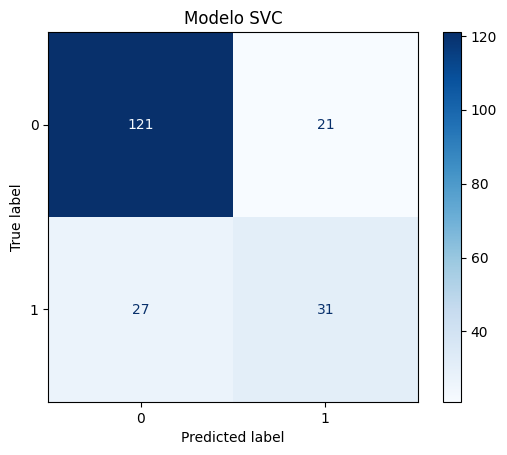

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       142
           1       0.60      0.53      0.56        58

    accuracy                           0.76       200
   macro avg       0.71      0.69      0.70       200
weighted avg       0.75      0.76      0.76       200



In [72]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title('Modelo SVC')

# Mostrar la figura
plt.show()

# Mostrar el informe de clasificación
print(classification_report(y_test, y_pred))

In [73]:
#f1-Score
print("f1-score:",metrics.f1_score(y_test, y_pred))

f1-score: 0.5636363636363636


In [74]:
metrics.f1_score(y_test, y_pred)

0.5636363636363636

In [75]:
#Crear un dataframe para guardar los resultados
dfResults = pd.DataFrame(columns=['Tipo', 'f1-score'])



dfResults = pd.concat([dfResults,
                       pd.DataFrame([{'Tipo': 'Lineal y método de retención',
                                      'f1-score': metrics.f1_score(y_test, y_pred)}])]
                      , ignore_index=True)

In [76]:
dfResults

,Tipo,f1-score
0,Lineal y método de retención,0.5636


#### 6.2. Lineal y validación cruzada (*Cross validation*)

##### Creación y entrenamiento del modelo

In [77]:
#Se establece las variables de entrada 'X' y la variable de salida 'y'

X = d.drop(columns ='bad_credit')
y = d['bad_credit']

# la validación cruzada se realiza sobre todo el dataset
X_Completo = X
y_Completo = y

In [78]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numerivas para posteriormente escalarlas
num_vars = numCols

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_Completo[num_vars] = scaler.fit_transform(X_Completo[num_vars])

X_Completo[num_vars].head()

,Customer ID,loan_duration_mo,loan_amount,payment_pcnt_income,time_in_residence,age_yrs,number_loans,dependents
0,0.0115,0.0294,0.0506,1.0000,1.0000,0.8571,0.3333,0.0000
1,0.5724,0.6471,0.3137,0.3333,0.3333,0.0536,0.0000,0.0000
2,0.1150,0.1176,0.1016,0.3333,0.6667,0.5357,0.0000,1.0000
3,0.8603,0.5588,0.4199,0.3333,1.0000,0.4643,0.0000,1.0000
4,0.3237,0.2941,0.2542,0.6667,1.0000,0.6071,0.3333,1.0000


In [79]:
# Guardar el scaler
joblib.dump(scaler, SCALER_PATH + './minmaxFull_GermanCredits.pkl')

['modelos/scaler/./minmaxFull_GermanCredits.pkl']

In [80]:
CV = 10 #Folks:  Pliegues
scoring = 'f1'


entries = []
accuracies = cross_val_score(modelSVC, X_Completo, y_Completo, cv=CV, scoring=scoring)

for fold_idx, accuracy in enumerate(accuracies):
    entries.append(( fold_idx, accuracy))
cv_df = pd.DataFrame(entries, columns=['fold_idx', 'f1-Score'])

#### Evaluación del modelo

In [81]:
print(cv_df)
print('f1-score:', cv_df['f1-Score'].mean())

   fold_idx  f1-Score
0         0    0.7059
1         1    0.3478
2         2    0.4906
3         3    0.5000
4         4    0.5660
5         5    0.5306
6         6    0.3448
7         7    0.6316
8         8    0.5185
9         9    0.5667
f1-score: 0.5202516177141064


### 7. Afinando el modelo (tuning)

Entre sus parámetros, encontramos:

- C: parámetro de regularización.
- kernel: especifica el tipo de kernel usado por el algoritmo (lineal, polinómico, radial, etc.).
- degree: grado de la función con kernel polinómico.
- gamma: coeficiente del kernel para ‘rbf’, ‘poly’ y ‘sigmoid’.
- probability: indica si se permite la estimación de probabilidades.
- max_iter: límite de iteraciones.
- decision_function_shape: permite establecer el método one-vs-one o one-vs-all.
- random_state: semilla para el generador de número pseudoaleatorios.

El parámetro "C" es el inverso del parámetro λ de regularización por lo cual, si tenemos un valor alto de nuestro parámetro tendremos una mayor varianza y la regularización será menor, mientras que por el contrario, si tenemos un valor bajo, tendremos un mayor efecto de la regularización. Ver: https://dzone.com/articles/support-vector-machines-tutorial

#### 7.1. Lineal e hiperparámetro *C*  (con validación cruzada - *Cross validation*)

##### Identificacion del mejor hiperparametro *C*

In [82]:
#Definicion del modelo
modelsvmL = svm.SVC(kernel='linear', probability = True, random_state = 0)

# Establecemos un grid con los valores de coste que queremos evaluar
grid_hiperparametros = {'C': [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7, 10]}

# definicion de la variable con el número de pliegues
CV = 10

# las metricas sobre las se evaluará el modelo
scoring = 'f1'

# Definimos la busqueda mediante 10-fold CV
grid_svmL = GridSearchCV(estimator = modelsvmL
                             , param_grid = grid_hiperparametros
                             , cv = CV
                             , scoring = scoring
                             , return_train_score = True
                             , verbose=4)



# Aplicamos la busqueda
grid_svmL.fit(X_Completo, y_Completo)

#gridsvmL.cv_results_.keys()

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV 1/10] END ......C=0.001;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 2/10] END ......C=0.001;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 3/10] END ......C=0.001;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 4/10] END ......C=0.001;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 5/10] END ......C=0.001;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 6/10] END ......C=0.001;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 7/10] END ......C=0.001;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 8/10] END ......C=0.001;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 9/10] END ......C=0.001;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 10/10] END .....C=0.001;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 1/10] END .......C=0.01;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 2/10] END .......C=0.01;, score=(train=0.0

GridSearchCV(cv=10,
             estimator=SVC(kernel='linear', probability=True, random_state=0),
             param_grid={'C': [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7,
                               10]},
             return_train_score=True, scoring='f1', verbose=4)

In [83]:
# Resultados
resultados = pd.DataFrame(grid_svmL.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(4)

,param_C,mean_test_score,std_test_score,mean_train_score,std_train_score
8,4.0000,0.5259,0.1074,0.6071,0.0158
9,5.0000,0.5253,0.1022,0.6070,0.0150
10,7.0000,0.5225,0.1021,0.6070,0.0151
7,3.0000,0.5216,0.1092,0.6065,0.0167


In [84]:
# Obtener los resultados del grid search
results_grid_svmL = pd.DataFrame(grid_svmL.cv_results_)

# Seleccionar las columnas deseadas
columns_grid_svmL = ['param_C']  + \
                    ['mean_test_score', 'std_test_score']  + \
                    [f'split{i}_test_score' for i in range(CV)]

# Filtrar y mostrar los resultados
results_grid_svmL_filtered = results_grid_svmL[columns_grid_svmL]

# Crear la columna scoreWithStd: f1 / std
results_grid_svmL_filtered['scoreWithStd'] = results_grid_svmL_filtered.apply(
    lambda row: row['mean_test_score'] / row['std_test_score'] if row['std_test_score'] != 0 else 0,
    axis=1
)

# Encuentra el índice del máximo valor en la columna scoreWithStd
indice_max_scoreWithStd = results_grid_svmL_filtered['scoreWithStd'].idxmax()

# Mostrar los scores promedios por cada parámetro
print(results_grid_svmL_filtered[['param_C', 'mean_test_score', 'std_test_score', 'scoreWithStd']])

    param_C  mean_test_score  std_test_score  scoreWithStd
0    0.0010           0.0000          0.0000        0.0000
1    0.0100           0.0000          0.0000        0.0000
2    0.1000           0.4560          0.1274        3.5797
3    0.3000           0.4804          0.1150        4.1763
4    0.5000           0.5093          0.1239        4.1118
5    1.0000           0.5203          0.1063        4.8939
6    2.0000           0.5168          0.1020        5.0682
7    3.0000           0.5216          0.1092        4.7780
8    4.0000           0.5259          0.1074        4.8947
9    5.0000           0.5253          0.1022        5.1394
10   7.0000           0.5225          0.1021        5.1164
11  10.0000           0.5172          0.0975        5.3022


In [85]:
# Top 3 de los mejores scores
results_grid_svmL_filtered.sort_values(by='scoreWithStd', ascending=False).head(3)[
    ['param_C',  'mean_test_score', 'std_test_score', 'scoreWithStd']]

,param_C,mean_test_score,std_test_score,scoreWithStd
11,10.0000,0.5172,0.0975,5.3022
9,5.0000,0.5253,0.1022,5.1394
10,7.0000,0.5225,0.1021,5.1164


#### Evaluación del modelo

In [86]:
# Seleccionar el registro correspondiente al índice máximo
registro_max_scoreWithStd = results_grid_svmL_filtered.loc[indice_max_scoreWithStd]

registro_max_scoreWithStd.transpose()

,11
param_C,10.0000
mean_test_score,0.5172
std_test_score,0.0975
split0_test_score,0.6400
split1_test_score,0.3478
split2_test_score,0.4815
split3_test_score,0.5385
split4_test_score,0.5455
split5_test_score,0.5000
split6_test_score,0.3667


In [87]:
# Guardar los resultados en el dataframe de resultados

# Guardar los resultados en el dataframe de resultados
dfResults = pd.concat([dfResults,
                       pd.DataFrame([{'Tipo': 'Polinómico e hiperparámetros: C y degree con validación cruzada',
                                      'f1-score': results_grid_svmL_filtered.loc[indice_max_scoreWithStd]['mean_test_score']}])],
                       ignore_index=True)
dfResults

,Tipo,f1-score
0,Lineal y método de retención,0.5636
1,Polinómico e hiperparámetros: C y degree con v...,0.5172


#### Creación del modelo final

In [88]:
# Usar los mejores parámetros para crear el modelo
modelsvmL.set_params(kernel='linear'
                     , C = results_grid_svmL_filtered.loc[indice_max_scoreWithStd]['param_C'])

modelsvmL.fit(X_Completo, y_Completo)

SVC(C=np.float64(10.0), kernel='linear', probability=True, random_state=0)

#### 7.2. Polinómico e hiperparámetros: *C* y *degree*  (con validación cruzada  - *Cross validation*)

##### Identificación del mejor hiperparametro *C* y *degree*

In [89]:
#Definición del modelo
modelsvmP = svm.SVC(kernel='poly', probability = True, random_state = 0)

# Establecemos un grid con los valores de coste que queremos evaluar
grid_hiperparametros = {'C': [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7, 10],
                        'degree': [2, 3]}

# definicion de la variable con el número de pliegues
CV = 10

# las metricas sobre las se evaluará el modelo
scoring = 'f1'

# Definimos la busqueda mediante 10-fold CV
grid_svmP = GridSearchCV(estimator = modelsvmP
                             , param_grid = grid_hiperparametros
                             , cv = CV
                             , scoring = scoring
                             , return_train_score = True
                             , verbose=4)


# Aplicamos la busqueda
grid_svmP.fit(X_Completo, y_Completo)

Fitting 10 folds for each of 24 candidates, totalling 240 fits
[CV 1/10] END C=0.001, degree=2;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 2/10] END C=0.001, degree=2;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 3/10] END C=0.001, degree=2;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 4/10] END C=0.001, degree=2;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 5/10] END C=0.001, degree=2;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 6/10] END C=0.001, degree=2;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 7/10] END C=0.001, degree=2;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 8/10] END C=0.001, degree=2;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 9/10] END C=0.001, degree=2;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 10/10] END C=0.001, degree=2;, score=(train=0.000, test=0.000) total time=   0.1s
[CV 1/10] END C=0.001, degree=3;, score=(train=0.000, test=0.000) total time=   0.1s
[

GridSearchCV(cv=10,
             estimator=SVC(kernel='poly', probability=True, random_state=0),
             param_grid={'C': [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7,
                               10],
                         'degree': [2, 3]},
             return_train_score=True, scoring='f1', verbose=4)

In [90]:
# Resultados
resultados = pd.DataFrame(grid_svmP.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(4)

,param_C,param_degree,mean_test_score,std_test_score,mean_train_score,std_train_score
14,3.0000,2,0.5589,0.0744,0.8126,0.0097
21,7.0000,3,0.5556,0.0648,0.9850,0.0031
19,5.0000,3,0.5525,0.0673,0.9775,0.0045
20,7.0000,2,0.5516,0.0700,0.8771,0.0082


In [91]:
# Obtener los resultados del grid search
results_grid_svmP = pd.DataFrame(grid_svmP.cv_results_)

# Seleccionar las columnas deseadas
columns_grid_svmP = ['param_C']  + \
                    ['param_degree']  + \
                    ['mean_test_score', 'std_test_score']  + \
                    [f'split{i}_test_score' for i in range(CV)]

# Filtrar y mostrar los resultados
results_grid_svmP_filtered = results_grid_svmP[columns_grid_svmP]

# Crear la columna scoreWithStd: f1 / std
results_grid_svmP_filtered['scoreWithStd'] = results_grid_svmP_filtered.apply(
    lambda row: row['mean_test_score'] / row['std_test_score'] if row['std_test_score'] != 0 else 0,
    axis=1
)

# Encuentra el índice del máximo valor en la columna scoreWithStd
indice_max_scoreWithStd = results_grid_svmP_filtered['scoreWithStd'].idxmax()

# Mostrar los scores promedios por cada parámetro
print(results_grid_svmP_filtered[['param_C', 'param_degree', 'mean_test_score', 'std_test_score', 'scoreWithStd']])

    param_C  param_degree  mean_test_score  std_test_score  scoreWithStd
0    0.0010             2           0.0000          0.0000        0.0000
1    0.0010             3           0.0000          0.0000        0.0000
2    0.0100             2           0.0000          0.0000        0.0000
3    0.0100             3           0.0000          0.0000        0.0000
4    0.1000             2           0.0754          0.0531        1.4204
5    0.1000             3           0.2485          0.1134        2.1902
6    0.3000             2           0.4245          0.0800        5.3066
7    0.3000             3           0.4463          0.0822        5.4281
8    0.5000             2           0.4732          0.0780        6.0646
9    0.5000             3           0.4890          0.0947        5.1627
10   1.0000             2           0.5056          0.0769        6.5707
11   1.0000             3           0.5347          0.0794        6.7351
12   2.0000             2           0.5444         

In [92]:
# Top 3 de los mejores scores
results_grid_svmP_filtered.sort_values(by='scoreWithStd', ascending=False).head(3)[
    ['param_C', 'param_degree', 'mean_test_score', 'std_test_score', 'scoreWithStd']]

,param_C,param_degree,mean_test_score,std_test_score,scoreWithStd
18,5.0000,2,0.5476,0.0635,8.6239
21,7.0000,3,0.5556,0.0648,8.5729
19,5.0000,3,0.5525,0.0673,8.2106


#### Evaluación del modelo

In [93]:
# Seleccionar el registro correspondiente al índice máximo
registro_max_scoreWithStd = results_grid_svmP_filtered.loc[indice_max_scoreWithStd]

registro_max_scoreWithStd.transpose()

,18
param_C,5.0000
param_degree,2.0000
mean_test_score,0.5476
std_test_score,0.0635
split0_test_score,0.6415
split1_test_score,0.4706
split2_test_score,0.5763
split3_test_score,0.5172
split4_test_score,0.6429
split5_test_score,0.4706


In [94]:

dfResults = pd.concat([dfResults,
                       pd.DataFrame({'Tipo': ['Polinómico e hiperparámetros: C y degree con validación cruzada'],
                                     'f1-score': [results_grid_svmP_filtered.loc[indice_max_scoreWithStd]['mean_test_score']]} )],
                       ignore_index=True)

#### Creación del modelo final

In [95]:
# Usar los mejores parámetros para crear el modelo
modelsvmP.set_params(kernel='poly'
                     , C = results_grid_svmP_filtered.loc[indice_max_scoreWithStd]['param_C']
                     , degree = int(results_grid_svmP_filtered.loc[indice_max_scoreWithStd]['param_degree'])
                    )

modelsvmP.fit(X_Completo, y_Completo)

SVC(C=np.float64(5.0), degree=2, kernel='poly', probability=True,
    random_state=0)

#### 7.3. Radial e hiperparámetros: *C* y *gamma*  (con validación cruzada  - *Cross validation*)

##### Identificación del mejor hiperparametro *C* y *gamma*

In [96]:
#Definición del modelo
modelsvmR = svm.SVC(kernel='rbf', probability = True, random_state = 0)



# Establecemos un grid con los valores de coste que queremos evaluar
grid_hiperparametros = {'C': [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7, 10],
                        'gamma': ['scale', 'auto']}

# definicion de la variable con el número de pliegues
CV = 10

# Definimos las metricas sobre las que queremos evaluar
scoring = 'f1'

# Definimos la busqueda mediante 10-fold CV
grid_svmR = GridSearchCV(estimator = modelsvmR
                             , param_grid = grid_hiperparametros
                             , cv = CV
                             , scoring = scoring
                             , return_train_score = True
                             , verbose=4)


# Aplicamos la busqueda
grid_svmR.fit(X_Completo, y_Completo)

Fitting 10 folds for each of 24 candidates, totalling 240 fits
[CV 1/10] END C=0.001, gamma=scale;, score=(train=0.000, test=0.000) total time=   0.2s
[CV 2/10] END C=0.001, gamma=scale;, score=(train=0.000, test=0.000) total time=   0.2s
[CV 3/10] END C=0.001, gamma=scale;, score=(train=0.000, test=0.000) total time=   0.2s
[CV 4/10] END C=0.001, gamma=scale;, score=(train=0.000, test=0.000) total time=   0.2s
[CV 5/10] END C=0.001, gamma=scale;, score=(train=0.000, test=0.000) total time=   0.2s
[CV 6/10] END C=0.001, gamma=scale;, score=(train=0.000, test=0.000) total time=   0.2s
[CV 7/10] END C=0.001, gamma=scale;, score=(train=0.000, test=0.000) total time=   0.2s
[CV 8/10] END C=0.001, gamma=scale;, score=(train=0.000, test=0.000) total time=   0.2s
[CV 9/10] END C=0.001, gamma=scale;, score=(train=0.000, test=0.000) total time=   0.4s
[CV 10/10] END C=0.001, gamma=scale;, score=(train=0.000, test=0.000) total time=   0.3s
[CV 1/10] END C=0.001, gamma=auto;, score=(train=0.000, 

GridSearchCV(cv=10, estimator=SVC(probability=True, random_state=0),
             param_grid={'C': [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7,
                               10],
                         'gamma': ['scale', 'auto']},
             return_train_score=True, scoring='f1', verbose=4)

In [97]:
# Resultados
resultados = pd.DataFrame(grid_svmR.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(4)

,param_C,param_gamma,mean_test_score,std_test_score,mean_train_score,std_train_score
22,10.0000,scale,0.5501,0.0857,0.9775,0.0031
16,4.0000,scale,0.5408,0.0805,0.9101,0.0050
18,5.0000,scale,0.5400,0.0724,0.9307,0.0074
20,7.0000,scale,0.5289,0.0833,0.9630,0.0052


In [98]:
# Obtener los resultados del grid search
results_grid_svmR = pd.DataFrame(grid_svmR.cv_results_)

# Seleccionar las columnas deseadas
columns_grid_svmR = ['param_C']  + \
                    ['param_gamma']  + \
                    ['mean_test_score', 'std_test_score']  + \
                    [f'split{i}_test_score' for i in range(CV)]

# Filtrar y mostrar los resultados
results_grid_svmR_filtered = results_grid_svmR[columns_grid_svmR]

# Crear la columna scoreWithStd: f1 / std
results_grid_svmR_filtered['scoreWithStd'] = results_grid_svmR_filtered.apply(
    lambda row: row['mean_test_score'] / row['std_test_score'] if row['std_test_score'] != 0 else 0,
    axis=1
)

# Encuentra el índice del máximo valor en la columna scoreWithStd
indice_max_scoreWithStd = results_grid_svmR_filtered['scoreWithStd'].idxmax()

# Mostrar los scores promedios por cada parámetro
print(results_grid_svmR_filtered[['param_C', 'param_gamma', 'mean_test_score', 'std_test_score', 'scoreWithStd']])

    param_C param_gamma  mean_test_score  std_test_score  scoreWithStd
0    0.0010       scale           0.0000          0.0000        0.0000
1    0.0010        auto           0.0000          0.0000        0.0000
2    0.0100       scale           0.0000          0.0000        0.0000
3    0.0100        auto           0.0000          0.0000        0.0000
4    0.1000       scale           0.0000          0.0000        0.0000
5    0.1000        auto           0.0000          0.0000        0.0000
6    0.3000       scale           0.1688          0.0940        1.7948
7    0.3000        auto           0.0000          0.0000        0.0000
8    0.5000       scale           0.3895          0.0873        4.4605
9    0.5000        auto           0.0000          0.0000        0.0000
10   1.0000       scale           0.4877          0.0932        5.2306
11   1.0000        auto           0.3177          0.0720        4.4103
12   2.0000       scale           0.5123          0.0823        6.2234
13   2

In [99]:
# Top 3 de los mejores scores
results_grid_svmR_filtered.sort_values(by='scoreWithStd', ascending=False).head(3)[
    ['param_C', 'param_gamma', 'mean_test_score', 'std_test_score', 'scoreWithStd']]

,param_C,param_gamma,mean_test_score,std_test_score,scoreWithStd
18,5.0000,scale,0.5400,0.0724,7.4575
16,4.0000,scale,0.5408,0.0805,6.7173
14,3.0000,scale,0.5217,0.0792,6.5835


#### Evaluación del modelo

In [100]:
# Seleccionar el registro correspondiente al índice máximo
registro_max_scoreWithStd = results_grid_svmR_filtered.loc[indice_max_scoreWithStd]

registro_max_scoreWithStd.transpose()

,18
param_C,5.0000
param_gamma,scale
mean_test_score,0.5400
std_test_score,0.0724
split0_test_score,0.6792
split1_test_score,0.5000
split2_test_score,0.5455
split3_test_score,0.5000
split4_test_score,0.6182
split5_test_score,0.4167


In [101]:
dfResults = pd.concat([dfResults,
                       pd.DataFrame([{'Tipo': 'Radial e hiperparámetros: C y gamma con validación cruzada',
                                      'f1-score': results_grid_svmR_filtered.loc[indice_max_scoreWithStd]['mean_test_score']}])],
                      ignore_index=True)



#dfResults = dfResults.append(pd.DataFrame(
#                {'Tipo': ['Radial e hiperparámetros: C y gamma con validación cruzada'],
#                 'f1-score':results_grid_svmR_filtered.loc[indice_max_scoreWithStd]['mean_test_score']}))
#dfResults

#### Creación del modelo final

In [102]:
# Usar los mejores parámetros para crear el modelo
modelsvmR.set_params(kernel='rbf'
                     , C = results_grid_svmR_filtered.loc[indice_max_scoreWithStd]['param_C']
                     , gamma = results_grid_svmR_filtered.loc[indice_max_scoreWithStd]['param_gamma']
                    )

modelsvmR.fit(X_Completo, y_Completo)

SVC(C=np.float64(5.0), probability=True, random_state=0)

### 8. Eligiendo el modelo

In [103]:
dfResults

,Tipo,f1-score
0,Lineal y método de retención,0.5636
1,Polinómico e hiperparámetros: C y degree con v...,0.5172
2,Polinómico e hiperparámetros: C y degree con v...,0.5476
3,Radial e hiperparámetros: C y gamma con valida...,0.5400


### Guardar modelo

In [104]:
#Se guardan los modelos de SVC

joblib.dump(modelsvmL, CLASIF_DIR_NAME + './SVC_CV_lineal.pkl')

joblib.dump(modelsvmP, CLASIF_DIR_NAME + './SVC_CV_poly.pkl')

joblib.dump(modelsvmR, CLASIF_DIR_NAME + './SVC_CV_rbf.pkl')


['modelos/clasificacion/./SVC_CV_rbf.pkl']

#### Referencias


- Maquinas de vectores de soporte

    - https://www.datacamp.com/community/tutorials/svm-classification-scikit-learn-python
    
    
- Tuning parametros SVM
    - https://github.com/CristinaGil/Ciencia-de-Datos-Python/blob/master/maquinas_vector_soporte.ipynb
    

- Hiperparametros y Kernels

    - https://ichi.pro/es/hiperparametros-de-svm-explicados-con-visualizaciones-22257741819931

    - https://jakevdp.github.io/PythonDataScienceHandbook/05.07-support-vector-machines.html


- *scikit-learn:*   
    - https://scikit-learn.org/stable/modules/svm.html



- *Gráficas con  seaborn:*
    - https://ichi.pro/es/como-utilizar-python-seaborn-para-analisis-de-datos-exploratorios-28897898172180


- *Multicolinealidad:*
    - https://www.analyticslane.com/2020/04/22/solucionar-la-multicolinealidad-con-vif/


- *Analítica de grandes datos:*
    - https://jdvelasq.github.io/courses/analitica-de-grandes-datos/index.html